In [551]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## df van excel bestand

In [552]:
df = pd.read_excel('AmesHousing.xlsx')
df

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,Mitchel,SLvl
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,Mitchel,1Story
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,Mitchel,SFoyer
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,Mitchel,1Story


## One-hot encoding

In [553]:
dummies_dataframe = pd.get_dummies(df[['House Style']], columns=['House Style'], drop_first=True)
dummies_dataframe

,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl
0,False,True,False,False,False,False,False
1,False,True,False,False,False,False,False
2,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False
4,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...
2925,False,False,False,False,False,False,True
2926,False,True,False,False,False,False,False
2927,False,False,False,False,False,True,False
2928,False,True,False,False,False,False,False


## concat nieuwe df aan originele df met dropped house style

In [554]:
df = pd.concat([df, dummies_dataframe], axis=1)
df = df.drop(['House Style'], axis=1)
df

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,False,True,False,False,False,False,False
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,False,True,False,False,False,False,False
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,False,True,False,False,False,False,False
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,False,True,False,False,False,False,False
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,Mitchel,False,False,False,False,False,False,True
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,Mitchel,False,True,False,False,False,False,False
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,Mitchel,False,False,False,False,False,True,False
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,Mitchel,False,True,False,False,False,False,False


Definieer X en y

In [588]:
X = df[['SalePrice', 'Lot Area'] + [col for col in df.columns if 'House Style' in col]]
X = X.loc[:, ~X.columns.duplicated()]
y = df['Full Bath']
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   SalePrice           2930 non-null   int64
 1   Lot Area            2930 non-null   int64
 2   House Style_1.5Unf  2930 non-null   bool 
 3   House Style_1Story  2930 non-null   bool 
 4   House Style_2.5Fin  2930 non-null   bool 
 5   House Style_2.5Unf  2930 non-null   bool 
 6   House Style_2Story  2930 non-null   bool 
 7   House Style_SFoyer  2930 non-null   bool 
 8   House Style_SLvl    2930 non-null   bool 
dtypes: bool(7), int64(2)
memory usage: 65.9 KB


## horizontaal en verticaal snijden van tabel 

In [556]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42)

## regressie model maken

In [557]:
reg_model = LinearRegression(fit_intercept=True)
reg_model.fit(X_train, y_train)
reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Bekijk coefficient

In [558]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg_model.coef_
})
print(coef_df)
print(f"\nIntercept: {reg_model.intercept_}")

              Feature  Coefficient
0           SalePrice     0.000003
1            Lot Area    -0.000001
2  House Style_1.5Unf    -0.253577
3  House Style_1Story    -0.017436
4  House Style_2.5Fin     0.250519
5  House Style_2.5Unf     0.277973
6  House Style_2Story     0.270941
7  House Style_SFoyer    -0.229409
8    House Style_SLvl     0.099954

Intercept: 0.8813755471300662


In [559]:
y_pred = reg_model.predict(X_test)
y_pred

array([1.70089946, 1.54968168, 1.82075032, 1.28016872, 1.28970314,
       1.45019331, 1.54828363, 1.66117749, 1.16460281, 2.53677126,
       1.94213338, 1.69407734, 1.44507083, 1.35033437, 1.46701032,
       1.52573187, 1.35685705, 1.80032685, 1.28609996, 1.11521418,
       1.53680484, 1.44724072, 1.83092724, 1.79886828, 1.77760772,
       2.18949733, 2.1993635 , 1.53102033, 1.81939075, 1.63373126,
       1.78286398, 1.44623887, 1.54578764, 1.22880722, 1.31449138,
       1.40909747, 1.46125671, 1.79957336, 1.78667225, 1.74047043,
       2.31342061, 1.65415275, 1.7740773 , 1.48156058, 1.28033722,
       2.34111085, 1.49298024, 1.38669484, 1.7347937 , 1.28479617,
       1.70147779, 1.31670769, 1.60456758, 1.39071503, 1.58641783,
       1.7974346 , 1.47762504, 1.02550584, 1.85334221, 1.43377586,
       1.06338507, 1.35005291, 1.16443824, 2.01182889, 1.70097727,
       1.49661093, 1.32122929, 1.68355769, 1.37561713, 1.52929158,
       1.71581579, 1.79925353, 1.94975582, 1.13407207, 1.42377

## zet prediction in df

In [560]:
prediction_df = pd.DataFrame(y_pred)
prediction_df = prediction_df.rename(columns={0: 'Predicted Full Bath'})
prediction_df

,Predicted Full Bath
0,1.700899
1,1.549682
2,1.820750
3,1.280169
4,1.289703
...,...
435,1.858803
436,1.447159
437,1.436563
438,1.341634


## merge prediction df met originele df

In [561]:
y_test_prediciton_merge = pd.concat([y_test.reset_index(drop=True), prediction_df], axis=1)
y_test_prediciton_merge.loc[y_test_prediciton_merge['Predicted Full Bath'].notna(), :]

,Full Bath,Predicted Full Bath
0,1,1.700899
1,1,1.549682
2,2,1.820750
3,1,1.280169
4,1,1.289703
...,...,...
435,2,1.858803
436,2,1.447159
437,2,1.436563
438,2,1.341634


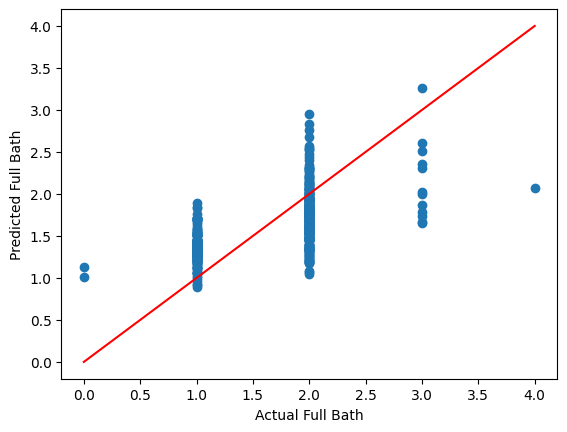

In [562]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test_prediciton_merge['Full Bath'], y_test_prediciton_merge['Predicted Full Bath'])

min_value = min(y_test_prediciton_merge['Full Bath'].min(), y_test_prediciton_merge['Predicted Full Bath'].min())
max_value = max(y_test_prediciton_merge['Full Bath'].max(), y_test_prediciton_merge['Predicted Full Bath'].max())
plt.plot([min_value, max_value], [min_value, max_value], color='red')

plt.xlabel('Actual Full Bath')
plt.ylabel('Predicted Full Bath')
plt.show()

In [580]:
mean_squared_error(y_test_prediciton_merge['Full Bath'], y_test_prediciton_merge['Predicted Full Bath'])

0.19867014095939275

In [564]:
mean_absolute_error(y_test_prediciton_merge['Full Bath'], y_test_prediciton_merge['Predicted Full Bath'])

0.37134883336704105

In [565]:
r2_score = reg_model.score(X_test, y_test)
r2_score

0.36479101435585815

Nieuwe prediction voor SalePrice met Lot Area, Year Built en Neighborhood

## df van excel bestand

In [566]:
df2 = pd.read_excel('AmesHousing.xlsx')
df2

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,Mitchel,SLvl
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,Mitchel,1Story
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,Mitchel,SFoyer
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,Mitchel,1Story


## One-hot encoding Neighborhood

In [567]:
dummies_neighborhood = pd.get_dummies(df2[['Neighborhood']], columns=['Neighborhood'], drop_first=True)
dummies_neighborhood

,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2926,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2927,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## concat nieuwe df aan originele df met dropped Neighborhood

In [568]:
df2 = pd.concat([df2, dummies_neighborhood], axis=1)
df2 = df2.drop(['Neighborhood'], axis=1)
df2

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,...,False,False,False,False,False,False,False,False,False,False
1,2,105000,yes,5,896,882.0,11622,1961,1,2,...,False,False,False,False,False,False,False,False,False,False
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,...,False,False,False,False,False,False,False,False,False,False
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,...,False,False,False,False,False,False,False,False,False,False
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,...,False,False,False,False,False,False,False,False,False,False
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,...,False,False,False,False,False,False,False,False,False,False
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,...,False,False,False,False,False,False,False,False,False,False
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,...,False,False,False,False,False,False,False,False,False,False


In [569]:
X2 = df2[['Lot Area', 'Year Built'] + [col for col in df2.columns if 'Neighborhood_' in col]]
X2 = X2.loc[:, ~X2.columns.duplicated()]
y2 = df2['SalePrice']
X2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Lot Area              2930 non-null   int64
 1   Year Built            2930 non-null   int64
 2   Neighborhood_Blueste  2930 non-null   bool 
 3   Neighborhood_BrDale   2930 non-null   bool 
 4   Neighborhood_BrkSide  2930 non-null   bool 
 5   Neighborhood_ClearCr  2930 non-null   bool 
 6   Neighborhood_CollgCr  2930 non-null   bool 
 7   Neighborhood_Crawfor  2930 non-null   bool 
 8   Neighborhood_Edwards  2930 non-null   bool 
 9   Neighborhood_Gilbert  2930 non-null   bool 
 10  Neighborhood_Greens   2930 non-null   bool 
 11  Neighborhood_GrnHill  2930 non-null   bool 
 12  Neighborhood_IDOTRR   2930 non-null   bool 
 13  Neighborhood_Landmrk  2930 non-null   bool 
 14  Neighborhood_MeadowV  2930 non-null   bool 
 15  Neighborhood_Mitchel  2930 non-null   bool 
 16  Neighborhood_NAme

## horizontaal en verticaal snijden van tabel

In [570]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.15,
    random_state=42)

## regressie model maken

In [571]:
reg_model2 = LinearRegression(fit_intercept=True)
reg_model2.fit(X_train2, y_train2)
reg_model2

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Bekijk coefficients

In [572]:
coef_df2 = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': reg_model2.coef_
})
print(coef_df2)
print(f"\nIntercept: {reg_model2.intercept_}")

                 Feature    Coefficient
0               Lot Area       1.909839
1             Year Built     878.930983
2   Neighborhood_Blueste  -40046.842362
3    Neighborhood_BrDale  -58566.840096
4   Neighborhood_BrkSide  -13675.178535
5   Neighborhood_ClearCr    8177.056835
6   Neighborhood_CollgCr   -1990.262277
7   Neighborhood_Crawfor   44176.488919
8   Neighborhood_Edwards  -35824.834067
9   Neighborhood_Gilbert  -14618.019543
10   Neighborhood_Greens   19903.426607
11  Neighborhood_GrnHill   84700.942034
12   Neighborhood_IDOTRR  -33892.599583
13  Neighborhood_Landmrk  -48885.864743
14  Neighborhood_MeadowV  -67500.192955
15  Neighborhood_Mitchel  -34322.879362
16    Neighborhood_NAmes  -23270.992870
17  Neighborhood_NPkVill  -28056.591069
18   Neighborhood_NWAmes     867.406191
19  Neighborhood_NoRidge  123306.668102
20  Neighborhood_NridgHt  107140.690962
21  Neighborhood_OldTown   -7461.904647
22    Neighborhood_SWISU     455.791735
23   Neighborhood_Sawyer  -35917.203381


In [573]:
y_pred2 = reg_model2.predict(X_test2)
y_pred2

array([121498.49419749, 105572.73066194, 165630.27016477, 193288.59722878,
        99575.42499109, 198064.33499041, 142007.77007236, 140343.54096369,
       109934.6778452 , 342938.23591991, 197608.0490832 , 215171.65098413,
        95902.17981788, 152252.20583223, 110057.98358747, 143591.3640284 ,
       151965.32504487, 200517.0304204 , 103733.73577272, 146155.18888483,
       210926.30731445, 138711.26614504, 198103.01191195, 211656.85141717,
       188131.84116893, 209823.43498706, 239129.4264163 , 195301.60187626,
       188564.55491973, 238746.13508769, 202555.36689301, 125416.04712795,
       232926.6731247 ,  97245.01610941, 133323.44435239, 100155.10173495,
       193849.72445225, 314113.72593448, 186706.46267098, 341424.42384346,
       328606.39662264, 199544.12225925, 209036.71080687, 148217.00559998,
       118083.33008609, 322184.30210107, 175368.14566536, 153562.47021191,
       167122.66446227, 153853.77001724, 184278.87543968, 137600.7892946 ,
       133791.9267358 , 1

## zet prediction in df

In [574]:
prediction_df2 = pd.DataFrame(y_pred2)
prediction_df2 = prediction_df2.rename(columns={0: 'Predicted SalePrice'})
prediction_df2

,Predicted SalePrice
0,121498.494197
1,105572.730662
2,165630.270165
3,193288.597229
4,99575.424991
...,...
435,320907.834241
436,171451.250723
437,151485.260190
438,112777.414457


## merge prediction df met originele df

In [575]:
y_test_prediciton_merge2 = pd.concat([y_test2.reset_index(drop=True), prediction_df2], axis=1)
y_test_prediciton_merge2.loc[y_test_prediciton_merge2['Predicted SalePrice'].notna(), :]

,SalePrice,Predicted SalePrice
0,161000,121498.494197
1,116000,105572.730662
2,196500,165630.270165
3,123600,193288.597229
4,126000,99575.424991
...,...,...
435,293000,320907.834241
436,103000,171451.250723
437,135500,151485.260190
438,138500,112777.414457


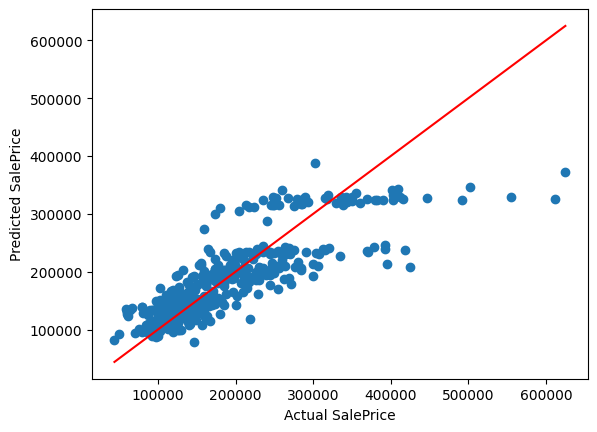

In [576]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test_prediciton_merge2['SalePrice'], y_test_prediciton_merge2['Predicted SalePrice'])

min_value2 = min(y_test_prediciton_merge2['SalePrice'].min(), y_test_prediciton_merge2['Predicted SalePrice'].min())
max_value2 = max(y_test_prediciton_merge2['SalePrice'].max(), y_test_prediciton_merge2['Predicted SalePrice'].max())
plt.plot([min_value2, max_value2], [min_value2, max_value2], color='red')

plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.show()

In [581]:
mean_squared_error(y_test_prediciton_merge2['SalePrice'], y_test_prediciton_merge2['Predicted SalePrice'])

2518416447.0913963

In [578]:
mean_absolute_error(y_test_prediciton_merge2['SalePrice'], y_test_prediciton_merge2['Predicted SalePrice'])

33824.93367037003

In [579]:
r2_score2 = reg_model2.score(X_test2, y_test2)
r2_score2

0.6721886124684764

# Experiment 7: SGDRegressor op Second Prediction (SalePrice) - lr=0.00005, epochs=4000

In [597]:
# Train SGD model with custom parameters on second prediction (X2, y2, SalePrice)
sgd_model7 = make_pipeline(StandardScaler(), SGDRegressor(learning_rate='constant', eta0=0.00005, max_iter=4000, random_state=42))
sgd_model7.fit(X_train2, y_train2)

# Make predictions
y_pred_sgd7 = sgd_model7.predict(X_test2)

# Create DataFrame for predictions
prediction_df_sgd7 = pd.DataFrame({
    'SalePrice': y_test2.values,
    'Predicted SalePrice': y_pred_sgd7
})

prediction_df_sgd7

,SalePrice,Predicted SalePrice
0,161000,121154.433079
1,116000,105559.275553
2,196500,163905.735565
3,123600,193532.971557
4,126000,99524.693469
...,...,...
435,293000,321067.004833
436,103000,171244.111251
437,135500,151200.179275
438,138500,116065.378708


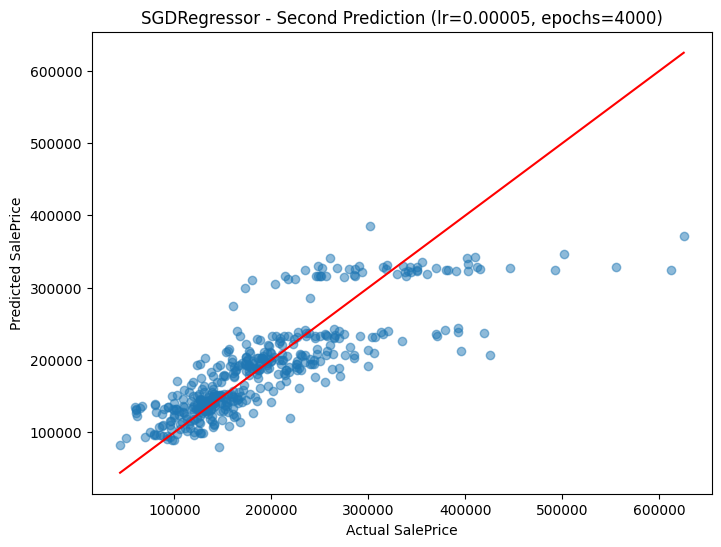

MSE: 2520756366.2709394
MAE: 33773.366087285634
R² Score: 0.6718840352990239


In [598]:
# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(prediction_df_sgd7['SalePrice'], prediction_df_sgd7['Predicted SalePrice'], alpha=0.5)

# Plot perfect prediction line
min_value_sgd7 = min(prediction_df_sgd7['SalePrice'].min(), prediction_df_sgd7['Predicted SalePrice'].min())
max_value_sgd7 = max(prediction_df_sgd7['SalePrice'].max(), prediction_df_sgd7['Predicted SalePrice'].max())
plt.plot([min_value_sgd7, max_value_sgd7], [min_value_sgd7, max_value_sgd7], color='red')

plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('SGDRegressor - Second Prediction (lr=0.00005, epochs=4000)')
plt.show()

# Metrics
mse_sgd7 = mean_squared_error(prediction_df_sgd7['SalePrice'], prediction_df_sgd7['Predicted SalePrice'])
mae_sgd7 = mean_absolute_error(prediction_df_sgd7['SalePrice'], prediction_df_sgd7['Predicted SalePrice'])
r2_sgd7 = sgd_model7.score(X_test2, y_test2)

print(f"MSE: {mse_sgd7}")
print(f"MAE: {mae_sgd7}")
print(f"R² Score: {r2_sgd7}")